# Time series structures


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from swot import add_mask_inside_swot, build_swath_polygon
from cstes import (
    swot_dir,
    drifters_dir,
    get_proj,
    lonlat2xy,
    zarr_dir,
    surface_drifters,
    depth_drifters,
    depth_100,
    depth_50,
    images_dir,
    U2,
    err_acc,
    drifters_structure,
)
from diagnosis import (
    update_dict,
    dataset_coloc_combs,
    dataset_coloc_combs,
    prepared_drifters,
    prepared_wd,
    prepared_alti,
    compute_variance_groupby,
    compute_variance,
)
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

depthcolor = {0: "navy", 15: "green", 50: "yellowgreen", 100: "yellow"}

# Characteritics :

In [2]:
structure = {
    "Dipole D1": dict(
        cmin=505,
        lomin=4,
        lamin=39.2,
        cmax=516,
        lomax=5.15,
        lamax=40,
        pass_=3,
    ),
    "Cyclone C1": dict(
        cmin=517,
        lomin=3.9,
        lamin=39.3,
        cmax=520,
        lomax=4.25,
        lamax=39.75,
        pass_=3,
    ),
    "Cyclone C2": dict(
        cmin=529,
        lomin=4.25,
        lamin=38.5,
        cmax=542,
        lomax=4.75,
        lamax=39.25,
        pass_=3,
    ),
    "Anticyclone A3": dict(
        cmin=479,
        lomin=4.5,
        lamin=41.9,
        cmax=492,
        lomax=5.1,
        lamax=42.3,
        pass_=3,
    ),
    "Cyclone C3": dict(
        cmin=500,
        lomin=4,
        lamin=40.1,
        cmax=511,
        lomax=4.8,
        lamax=40.65,
        pass_=3,
    ),
    "BioSWOT-Med": dict(
        cmin=500,
        lomin=4.75,
        lamin=40.3,
        cmax=523,
        lomax=5.5,
        lamax=41.3,
        pass_=3,
    ),
    "BioSWOT-Med front F1": dict(
        cmin=500,
        lomin=4.75,
        lamin=40.3,
        cmax=520,
        lomax=5.5,
        lamax=41.3,
        pass_=3,
    ),
    "BioSWOT-Med anticyclone A1": dict(
        cmin=500,
        lomin=4.75,
        lamin=40.3,
        cmax=523,
        lomax=5.5,
        lamax=41.3,
        pass_=3,
    ),
    "FaSt-SWOT anticyclone A2": dict(
        cmin=501,
        lomin=1.25,
        lamin=39.5,
        cmax=524,
        lomax=2,
        lamax=40.2,
        pass_=16,
    ),
}
for k in structure:
    structure[k].update({"drifter_id": drifters_structure[k]})

In [3]:
def sel_structure(dfr, cmin, lomin, lamin, cmax, lomax, lamax, pass_, drifter_id):
    # id = dfr[(dfr.longitude>=lomin)&(dfr.longitude<=lomax)&(dfr.latitude>=lamin)&(dfr.latitude<=lamax)&(dfr.cycle_number>=cmin)&(dfr.cycle_number<=cmax)].drifter_id.unique()
    id = drifter_id
    dfr = dfr[
        (
            (dfr.drifter_id.isin(id))
            & (dfr.longitude >= lomin)
            & (dfr.longitude <= lomax)
            & (dfr.latitude >= lamin)
            & (dfr.latitude <= lamax)
            & (dfr.cycle_number >= cmin)
            & (dfr.cycle_number <= cmax)
            # &(~((dfr.longitude<4.75)&(dfr.latitude<40.6)))
        )
    ]
    return dfr


def generate_0_15m_coloc_dataframe(freq_band):

    DT = 12

    # SURFACE
    base_dic = dict(
        dt="12h",
        drifter_preprocess="spectral_decomp",
        drifter_preprocess_param=freq_band,
        alti_product_key="swot2km",
        alti_diff_method="fromduacsv",
        alti_diff_method_param="",
        ggd_var="fromduacsv",
        wd_product_key="era5",
        wd_model="rio",
        wd_depth="0",
    )

    comb_list = [base_dic]

    ds0 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
    # ds0 = ds0.where(ds0.depth==0, drop=True)
    # distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
    # ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)
    # ds0 = ds0.where(ds0.time_to_swot/pd.Timedelta('1h')<DT, drop=True)
    # ds0 = ds0.where((abs(ds0.ggde)<1e-4) & (abs(ds0.ggdn)<1e-4), drop=True)
    # ds0 = ds0.where(ds0.distance_to_coast>distance_to_coast_max, drop=True)

    df0 = ds0.to_dataframe().reset_index().set_index("row_number")

    # DEPTH 15M
    base_dic = dict(
        dt="12h",
        drifter_preprocess="spectral_decomp",
        drifter_preprocess_param=freq_band,
        alti_product_key="swot2km",
        alti_diff_method="fromduacsv",
        alti_diff_method_param="",
        ggd_var="fromduacsv",
        wd_product_key="era5",
        wd_model="rio",
        wd_depth="15",
    )

    comb_list = [
        base_dic,
    ]

    ds15 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
    # ds15 =ds15.where(ds15.depth==15, drop=True)
    # distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
    # ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)
    # ds15 = ds15.where(ds15.time_to_swot/pd.Timedelta('1h')<DT, drop=True)
    # ds15 = ds15.where((abs(ds15.ggde)<1e-4) & (abs(ds15.ggdn)<1e-4), drop=True)
    # ds15 = ds15.where(ds15.distance_to_coast>distance_to_coast_max, drop=True)

    df15 = ds15.to_dataframe().reset_index().set_index("row_number")

    return df0, df15

In [4]:
def get_DF_spectral_decomp():
    DF15 = dict()
    DF0 = dict()

    for spectral_band in ["", "LF", "inertial", "diurnal", "semidiurnal", "HF"]:
        df0, df15 = generate_0_15m_coloc_dataframe(spectral_band)
        dfs = prepared_alti(
            dt="12h",
            drifter_preprocess="",
            drifter_preprocess_param="",
            alti_product_key="swot2km",
            alti_diff_method="xarray_diff",
            alti_diff_method_param="",
        )

        def concat(df, dfs):
            df = pd.concat(
                [
                    df,
                    dfs[
                        [
                            "vorticity_etaf",
                            "strain_s_etaf",
                            "strain_n_etaf",
                        ]
                    ],
                ],
                axis=1,
            ).dropna()
            df["f"] = 2 * 2 * np.pi / 86164.1 * np.sin(df.latitude * np.pi / 180)
            fo = df.f.mean()
            df["strain_f"] = np.sqrt(df.strain_n_etaf**2 + df.strain_s_etaf**2)
            df["strain"] = (
                df.strain_f * df.f
            )  # .assign_attrs({'long_name':r'$\sigma/|f|$'})
            df["vorticity"] = (
                df.vorticity_etaf * df.f
            )  # .assign_attrs({'long_name':r'$\zeta/f$'})
            df[
                "vorticity_f"
            ] = df.vorticity_etaf  # .assign_attrs({'long_name':r'$\zeta/f$'})
            df["omega"] = df.strain**2 - df.vorticity**2
            return df

        DF0[spectral_band] = concat(df0, dfs)
        DF15[spectral_band] = concat(df15, dfs)

    DF0["All"] = DF0[""]
    DF15["All"] = DF15[""]
    return DF0, DF15


def sel_structure_in_DF(
    DF0, DF15, cmin, lomin, lamin, cmax, lomax, lamax, pass_, drifter_id
):
    DF0_ = {
        k: sel_structure(
            DF0[k], cmin, lomin, lamin, cmax, lomax, lamax, pass_, drifter_id
        )
        for k in DF0
    }
    DF15_ = {
        k: sel_structure(
            DF15[k], cmin, lomin, lamin, cmax, lomax, lamax, pass_, drifter_id
        )
        for k in DF15
    }
    bbox = [lomin, lomax, lamin, lamax]
    return DF0_, DF15_, bbox

In [6]:
DF0, DF15 = get_DF_spectral_decomp()

12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio15
Identified SWOT and drifter outliers have been removed
12h_spectral_decomp_all_med_variational_10min_v1__LF__swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
12h_spectral_decomp_all_med_variational_10min_v1__LF__swot2km_fromduacsv__fromduacsv__era5_rio15
Identified SWOT and drifter outliers have been removed
12h_spectral_decomp_all_med_variational_10min_v1__inertial__swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
12h_spectral_decomp_all_med_variational_10min_v1__inertial__swot2km_fromduacsv__fromduacsv__era5_rio15
Identified SWOT and drifter outliers have been removed
12h_spectral_decomp_all_med_variational_10min_v1__diurnal__swot2km_fromduacsv__from

# Time series

In [7]:
from matplotlib.gridspec import GridSpec
from cstes import U


def plot_timeseries_all(DF, i):
    df = DF["All"]

    fig, ax = plt.subplots(
        1,
        1,
        figsize=(5, 3),
        frameon=False,
        subplot_kw=dict(projection=ccrs.PlateCarree()),
    )
    did = df.drifter_id.unique()
    kw = dict(transform=crs, cmap="RdBu_r", vmin=-0.2, vmax=0.05)
    pass_ = int(df.pass_number.iloc[0])
    dss = xr.open_dataset(
        os.path.join(
            zarr_dir,
            "before_coloc",
            "preprocessed_swot",
            product,
            "general",
            f"pass{pass_}_{product}_general.nc",
        )
    )
    dss = xr.merge(
        [
            dss,
            xr.open_dataset(
                os.path.join(
                    zarr_dir,
                    "before_coloc",
                    "preprocessed_swot",
                    product,
                    "diff_only",
                    f"pass{pass_}_{product}_diff_only.nc",
                )
            ),
        ],
        compat="override",
    )
    dss["time"] = dss.time - np.timedelta64(946684800000000000, "ns")

    dss.sel(cycle_number=512).etaf.plot(x="longitude", y="latitude", ax=ax, **kw)
    print(did[i])
    df_ = df[df.drifter_id == did[i]]
    df_.set_index("datetime").plot.scatter(
        x="longitude",
        y="latitude",
        s=(df_.datetime - df_.datetime.min()) / pd.Timedelta("1d"),
        ax=ax,
        transform=crs,
        color=depthcolor[df_.depth.mean()],
    )
    ax.set_title(did[i])
    ax.set_extent(bbox)
    gl = ax.gridlines(
        draw_labels=True,
    )
    gl.top_labels = False
    gl.right_labels = False

    fig, axs = plt.subplots(5, 2, figsize=(16, 16), frameon=False, sharex=True)
    axs = axs.flatten()
    j = 0
    for spectral_band in ["All", "LF"]:
        # Time series
        df = DF[spectral_band]
        df_ = df[df.drifter_id == did[i]]
        df_ = df_.set_index("datetime")

        ax = axs[j]
        for v in ["acc", "cor", "ggd", "wd"]:
            (df_[v + "e"] / U).dropna().plot(
                ax=ax, color=c0[v], ls="", marker=".", markersize=1
            )
        (df_["sum" + "e"] / U).to_xarray().plot(
            ax=ax, color="k", marker=".", ls="", markersize=1
        )
        for t in (
            dss.time.sel(
                cycle_number=slice(df_.cycle_number.min(), df_.cycle_number.max())
            )
            .mean("num_lines")
            .values
        ):
            ax.axvline(t, ls=":", color="grey")
        ax.grid()
        ax.set_title(spectral_band)

        ax = axs[j + 1]
        for v in ["acc", "cor", "ggd", "wd"]:
            (df_[v + "n"] / U).dropna().plot(
                ax=ax, color=c0[v], ls="", marker=".", markersize=1
            )
        (df_["sum" + "n"] / U).to_xarray().plot(
            ax=ax, color="k", marker=".", ls="", markersize=1
        )
        for t in (
            dss.time.sel(
                cycle_number=slice(df_.cycle_number.min(), df_.cycle_number.max())
            )
            .mean("num_lines")
            .values
        ):
            ax.axvline(t, ls=":", color="grey")
        ax.grid()
        j += 2

    for spectral_band in ["inertial", "diurnal", "semidiurnal"]:
        # Time series
        df = DF[spectral_band]
        df_ = df[df.drifter_id == did[i]]
        df_ = df_.set_index("datetime")

        ax = axs[j]
        for v in ["acc", "cor", "wd"]:
            (df_[v + "e"] / U).dropna().plot(
                ax=ax, color=c0[v], ls="", marker=".", markersize=1
            )
        # (df_['sum'+'e']/U).to_xarray().plot(ax=ax, color=c0['sum'], marker='.',ls='', markersize=1)
        ((df_["acce"] + df_["core"] + df_["wde"]) / U).dropna().plot(
            ax=ax, color="k", ls="", marker=".", markersize=1
        )
        for t in (
            dss.time.sel(
                cycle_number=slice(df_.cycle_number.min(), df_.cycle_number.max())
            )
            .mean("num_lines")
            .values
        ):
            ax.axvline(t, ls=":", color="grey")
        ax.grid()
        ax.set_title(spectral_band)

        ax = axs[j + 1]
        for v in ["acc", "cor", "wd"]:
            (df_[v + "n"] / U).dropna().plot(
                ax=ax, color=c0[v], ls="", marker=".", markersize=1
            )
        ((df_["accn"] + df_["corn"] + df_["wdn"]) / U).dropna().plot(
            ax=ax, color="k", ls="", marker=".", markersize=1
        )
        for t in (
            dss.time.sel(
                cycle_number=slice(df_.cycle_number.min(), df_.cycle_number.max())
            )
            .mean("num_lines")
            .values
        ):
            ax.axvline(t, ls=":", color="grey")
        ax.grid()
        j += 2

    # fig.tight_layout()
    # fig.savefig(os.path.join(zarr_dir, 'diag_files', 'synth_timeseries_images', did[i]+'.pdf'))
    # plt.close()

NameError: name 'product' is not defined

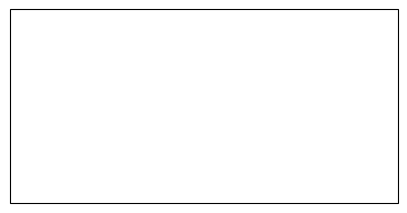

In [8]:
DF0_, DF15_, bbox = sel_structure_in_DF(DF0, DF15, **structure["Dipole D1"])
plot_timeseries_all(DF15_, 0)
plot_timeseries_all(DF15_, 1)
plot_timeseries_all(DF15_, 2)

NameError: name 'product' is not defined

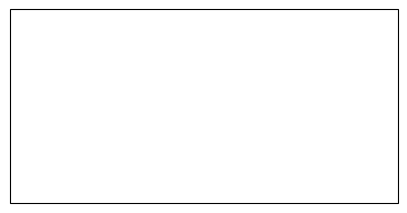

In [9]:
DF0_, DF15_, bbox = sel_structure_in_DF(DF0, DF15, **structure["Cyclone C2"])
plot_timeseries_all(DF0_, 15)